*DESCRITIVA*

In [2]:
import pandas as pd

In [10]:
df = pd.read_csv("dados/dados_olimpiadas_exame.csv")

In [8]:
# df_bow = pd.read_csv(
#     "dados/df_final_bow.csv",
#     low_memory=False
# )

In [11]:
texto = " ".join(df["titulo"].astype(str))

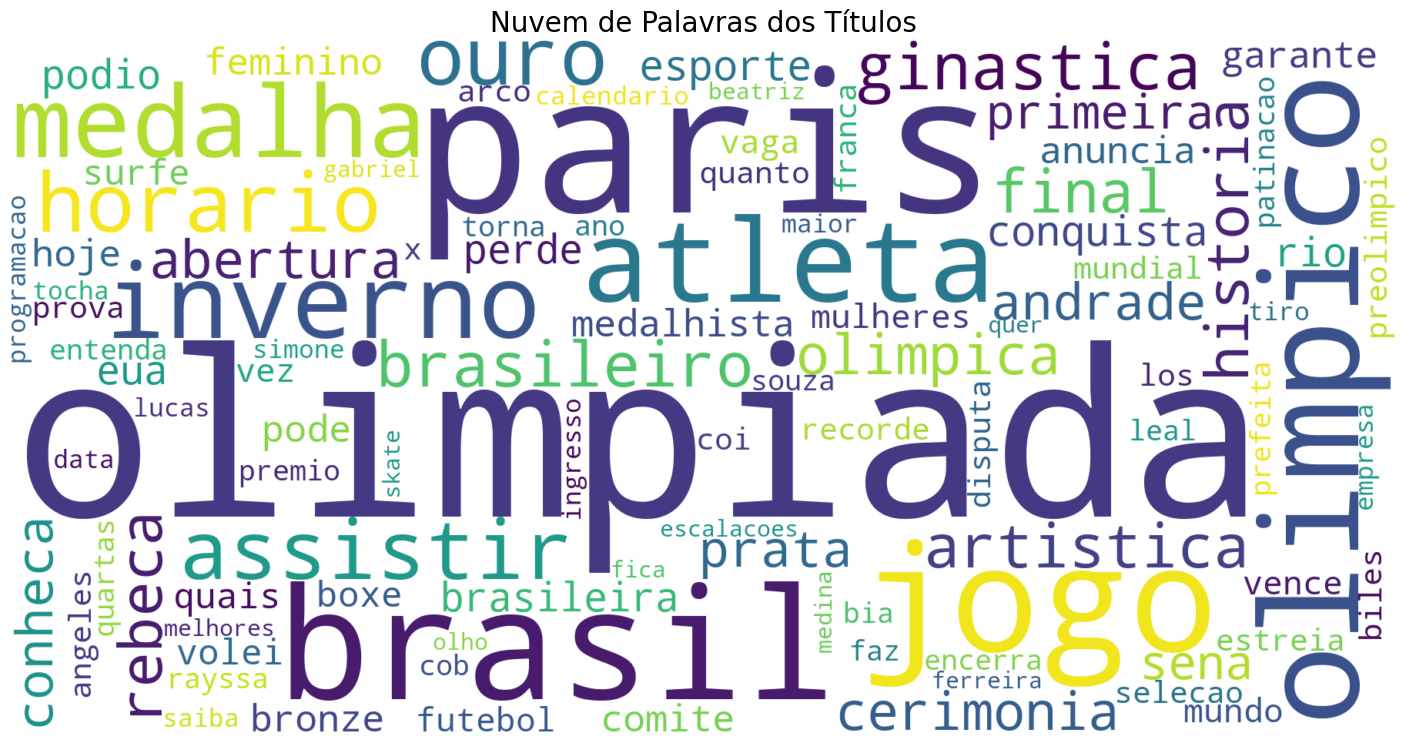

In [17]:
# deixar minúsculo
df["titulo"] = df["titulo"].astype(str).str.lower()

# remover acentos
df["titulo"] = df["titulo"].apply(unidecode)

# remover pontuação e números
df["titulo"] = df["titulo"].apply(
    lambda x: re.sub(r"[^a-z\s]", "", x)
)

# stopwords em português
stopwords_pt = stopwords.words("portuguese")
stopwords_pt = [unidecode(palavra) for palavra in stopwords_pt]
stopwords_pt = set(stopwords_pt)

# adicionar palavras extras
stopwords_extra = {
    "pra", "vai", "sobre", "ainda", "ser",
    "ter", "anos", "contra", "apos",
    "entre", "durante", "dia", "disse",
    "segundo","diz","veja","onde"
}

stopwords_final = stopwords_pt.union(stopwords_extra)

# função para remover stopwords
def remover_stopwords(texto):
    tokens = texto.split()
    tokens = [
        token for token in tokens
        if token not in stopwords_final
    ]
    return tokens

# aplicar limpeza
df["tokens_sem_stopwords"] = df["titulo"].apply(remover_stopwords)

# juntar novamente em texto
df["texto_sem_stopwords"] = df["tokens_sem_stopwords"].str.join(" ")

# juntar todos os títulos
texto = " ".join(df["texto_sem_stopwords"])

# gerar nuvem
wordcloud = WordCloud(
    width=1800,
    height=900,
    background_color="white",
    max_words=100,
    collocations=False
).generate(texto)

# plotar
plt.figure(figsize=(18,9))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nuvem de Palavras dos Títulos", fontsize=20)
plt.show()

In [18]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

# juntar todos os tokens
tokens = []

for lista in df["tokens_sem_stopwords"]:
    tokens.extend(lista)

# contar frequências
freq = Counter(tokens)

# top 20
top20 = freq.most_common(20)

# dataframe
df_freq = pd.DataFrame(top20, columns=["Palavra", "Frequência"])

print(df_freq)

       Palavra  Frequência
0   olimpiadas         127
1        paris         106
2       brasil          63
3        jogos          54
4    olimpicos          35
5      inverno          32
6    olimpiada          32
7     assistir          21
8      atletas          21
9    ginastica          19
10     medalha          19
11        ouro          18
12   artistica          17
13       final          16
14    historia          16
15      rebeca          16
16    olimpico          13
17      atleta          13
18   cerimonia          13
19    abertura          13
